## Import Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

## Load Data

In [5]:
df_online_retail = pd.read_csv(
    "Online Retail.csv",
    sep=";"
)

df_online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,01/12/2010 08:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,01/12/2010 08:26,"3,39",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,01/12/2010 08:26,"2,75",17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,01/12/2010 08:26,"3,39",17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,01/12/2010 08:26,"3,39",17850.0,United Kingdom


In [6]:
df_online_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37013 entries, 0 to 37012
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    37013 non-null  object 
 1   StockCode    37012 non-null  object 
 2   Description  36895 non-null  object 
 3   Quantity     37012 non-null  float64
 4   InvoiceDate  37012 non-null  object 
 5   UnitPrice    37012 non-null  object 
 6   CustomerID   24364 non-null  float64
 7   Country      37012 non-null  object 
dtypes: float64(2), object(6)
memory usage: 2.3+ MB


In [7]:
# Ubah UnitPrice Menjadi Float
df_online_retail["UnitPrice"] = (
    df_online_retail["UnitPrice"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

In [8]:
# Hapus Missing Value
df_online_retail = df_online_retail.dropna()

# Hapus Data Tidak Valid
df_online_retail = df_online_retail[
    (df_online_retail["Quantity"] > 0)
    &
    (df_online_retail["UnitPrice"] > 0)
]

# Buang Outlier Ekstrem
df_online_retail = df_online_retail[
    (df_online_retail["Quantity"] < 100)
    &
    (df_online_retail["UnitPrice"] < 50)
]

# Cek Ukuran Data
print(df_online_retail.shape)

(23468, 8)


In [9]:
# Memilih variabel clusterring
data_online_retail = df_online_retail[["Quantity", "UnitPrice"]]

data_online_retail.head()

,Quantity,UnitPrice
0,6.0,2.55
1,6.0,3.39
2,8.0,2.75
3,6.0,3.39
4,6.0,3.39


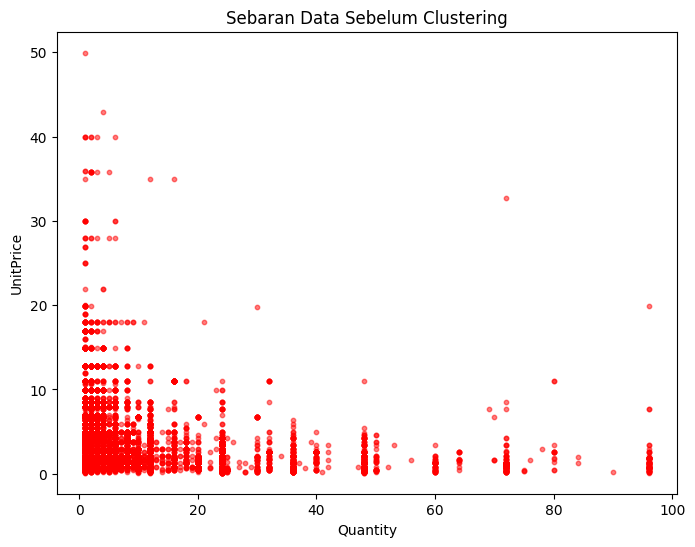

In [10]:
# Visualisasi Sebaran Data
plt.figure(figsize=(8,6))

plt.scatter(
    data_online_retail["Quantity"],
    data_online_retail["UnitPrice"],
    s=10,
    c="red",
    alpha=0.5
)

plt.xlabel("Quantity")
plt.ylabel("UnitPrice")
plt.title("Sebaran Data Sebelum Clustering")

plt.show()

In [11]:
# Ubah menjadi data array
x_array = np.array(data_online_retail)

print(x_array)

[[ 6.    2.55]
 [ 6.    3.39]
 [ 8.    2.75]
 ...
 [ 6.    2.95]
 [ 6.    2.95]
 [40.    1.25]]


## Normalisasi

In [12]:
scaler = MinMaxScaler()

x_scaled = scaler.fit_transform(x_array)

print(x_scaled)

[[0.05263158 0.0487658 ]
 [0.05263158 0.06562312]
 [0.07368421 0.05277945]
 ...
 [0.05263158 0.0567931 ]
 [0.05263158 0.0567931 ]
 [0.41052632 0.0226771 ]]


## Membuat Model

In [13]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(x_scaled)

print(kmeans.labels_)

[0 0 0 ... 0 0 2]


In [14]:
df_online_retail["kluster"] = kmeans.labels_

df_online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,kluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,01/12/2010 08:26,2.55,17850.0,United Kingdom,0
1,536365,71053,WHITE METAL LANTERN,6.0,01/12/2010 08:26,3.39,17850.0,United Kingdom,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,01/12/2010 08:26,2.75,17850.0,United Kingdom,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,01/12/2010 08:26,3.39,17850.0,United Kingdom,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,01/12/2010 08:26,3.39,17850.0,United Kingdom,0


In [15]:
print(
    df_online_retail["kluster"]
    .value_counts()
)

kluster
0    20172
2     2599
1      697
Name: count, dtype: int64


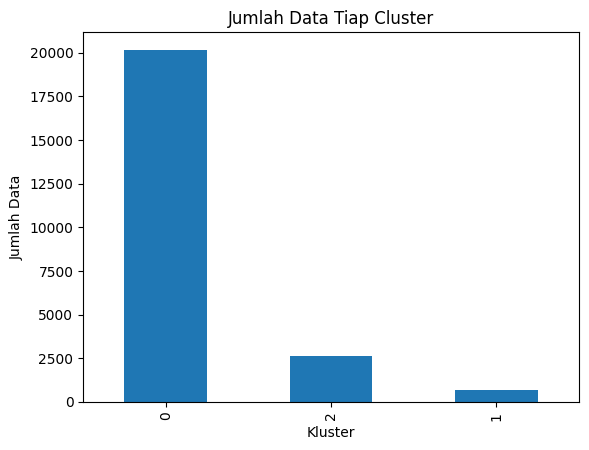

In [16]:
# Visualisasi Jumlah Data Tiap Cluster
df_online_retail["kluster"].value_counts().plot(
    kind="bar"
)

plt.title("Jumlah Data Tiap Cluster")
plt.xlabel("Kluster")
plt.ylabel("Jumlah Data")

plt.show()

In [17]:
# Evaluasi Kmeans
score = silhouette_score(
    x_scaled,
    kmeans.labels_
)

print("Silhouette Score :", score)

Silhouette Score : 0.6113936930582735


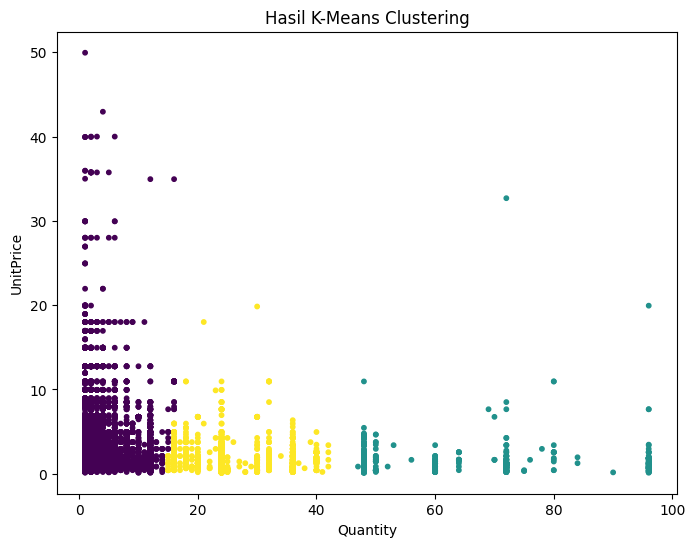

In [18]:
# Visualisasi Hasil Clustering
plt.figure(figsize=(8,6))

plt.scatter(
    data_online_retail["Quantity"],
    data_online_retail["UnitPrice"],
    c=df_online_retail["kluster"],
    cmap="viridis",
    s=10
)

plt.xlabel("Quantity")
plt.ylabel("UnitPrice")
plt.title("Hasil K-Means Clustering")

plt.show()

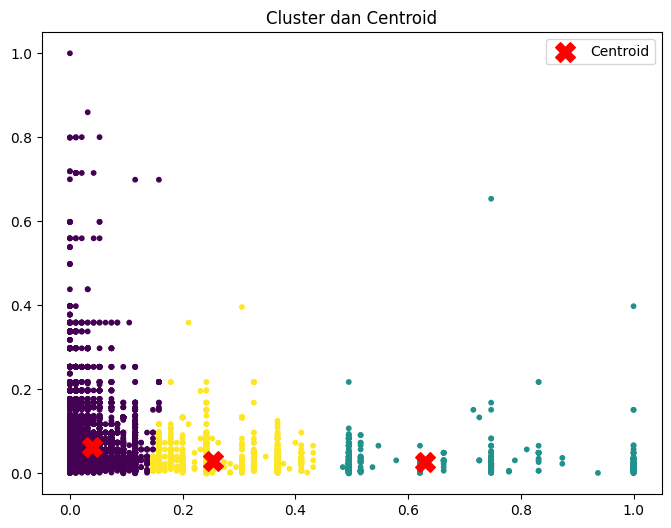

In [19]:
# Visualisasi cluster + centeroid
plt.figure(figsize=(8,6))

plt.scatter(
    x_scaled[:,0],
    x_scaled[:,1],
    c=kmeans.labels_,
    cmap="viridis",
    s=10
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    c="red",
    marker="X",
    label="Centroid"
)

plt.title("Cluster dan Centroid")
plt.legend()

plt.show()

In [20]:
# Analisis Hasil Cluster
print(
    df_online_retail
    .groupby("kluster")
    [["Quantity","UnitPrice"]]
    .mean()
)

          Quantity  UnitPrice
kluster                      
0         4.687289   3.269530
1        60.875179   1.413458
2        25.071951   1.558846
